<a href="https://colab.research.google.com/github/Anjali19566/Netflix-Content-Analytics-and-Recommendation-System-using-Apache-Spark-MLlib/blob/main/BDV_PROJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

print(os.listdir('/content'))

['.config', 'sample_data']


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [ ]:
import os
print(os.listdir('/content'))

['.config', 'netflix_titles.csv', 'sample_data']


In [ ]:
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("NetflixAnalytics") \
    .getOrCreate()

print("Spark Started")

Spark Started


In [ ]:
netflix_df = spark.read.csv(
    "netflix_titles.csv",
    header=True,
    inferSchema=True
)

netflix_df.show(5)

+-------+-------+--------------------+---------------+--------------------+-------------+------------------+------------+------+---------+--------------------+--------------------+
|show_id|   type|               title|       director|                cast|      country|        date_added|release_year|rating| duration|           listed_in|         description|
+-------+-------+--------------------+---------------+--------------------+-------------+------------------+------------+------+---------+--------------------+--------------------+
|     s1|  Movie|Dick Johnson Is Dead|Kirsten Johnson|                NULL|United States|September 25, 2021|        2020| PG-13|   90 min|       Documentaries|As her father nea...|
|     s2|TV Show|       Blood & Water|           NULL|Ama Qamata, Khosi...| South Africa|September 24, 2021|        2021| TV-MA|2 Seasons|International TV ...|After crossing pa...|
|     s3|TV Show|           Ganglands|Julien Leclercq|Sami Bouajila, Tr...|         NULL|Septem

In [ ]:
netflix_df = netflix_df.dropna(
    subset=["title","listed_in"]
)

netflix_df = netflix_df.dropDuplicates()

print("Rows:", netflix_df.count())

Rows: 8806


In [ ]:
import pandas as pd
import numpy as np

users = pd.DataFrame({
    "user_id": range(1,1001),
    "age": np.random.randint(18,60,1000),
    "country": np.random.choice(
        ["India","USA","UK","Canada"],
        1000
    )
})

users.to_csv(
    "users.csv",
    index=False
)

users_df = spark.read.csv(
    "users.csv",
    header=True,
    inferSchema=True
)

users_df.show()

+-------+---+-------+
|user_id|age|country|
+-------+---+-------+
|      1| 25|  India|
|      2| 54|    USA|
|      3| 18|  India|
|      4| 30|    USA|
|      5| 37| Canada|
|      6| 24| Canada|
|      7| 58| Canada|
|      8| 59|    USA|
|      9| 49|     UK|
|     10| 18|     UK|
|     11| 57|  India|
|     12| 32|     UK|
|     13| 37|    USA|
|     14| 46|     UK|
|     15| 49|    USA|
|     16| 44|     UK|
|     17| 54|     UK|
|     18| 48|    USA|
|     19| 57|     UK|
|     20| 18|    USA|
+-------+---+-------+
only showing top 20 rows


In [ ]:
from pyspark.sql.functions import row_number
from pyspark.sql.window import Window

window_spec = Window.orderBy("title")

netflix_df = netflix_df.withColumn(
    "movie_id",
    row_number().over(window_spec)
)

netflix_df.select(
    "movie_id",
    "title"
).show(10)

+--------+--------------------+
|movie_id|               title|
+--------+--------------------+
|       1|"Behind ""The Cov...|
|       2|"Escape from the ...|
|       3|"Gabriel ""Fluffy...|
|       4|"Waiting for ""Su...|
|       5|              #Alive|
|       6|#AnneFrank - Para...|
|       7|   #FriendButMarried|
|       8| #FriendButMarried 2|
|       9|               #Roxy|
|      10|           #Rucker50|
+--------+--------------------+
only showing top 10 rows


In [ ]:
import random

movies = netflix_df.select(
    "movie_id"
).toPandas()["movie_id"].tolist()

watch_data = []

for i in range(50000):

    user = random.randint(1,1000)

    movie = random.choice(movies)

    rating = random.randint(1,5)

    watch_time = random.randint(10,180)

    watch_data.append(
        [user,movie,rating,watch_time]
    )

watch = pd.DataFrame(
    watch_data,
    columns=[
        "user_id",
        "movie_id",
        "rating",
        "watch_time"
    ]
)

watch.to_csv(
    "watch_history.csv",
    index=False
)

In [ ]:
watch_df = spark.read.csv(
    "watch_history.csv",
    header=True,
    inferSchema=True
)

watch_df.show()

+-------+--------+------+----------+
|user_id|movie_id|rating|watch_time|
+-------+--------+------+----------+
|    963|    5810|     5|       159|
|    352|    2919|     2|        64|
|    959|    3473|     4|        41|
|    405|    4549|     5|       127|
|    498|    2372|     3|        41|
|    568|    1984|     3|        20|
|    412|    2597|     3|        95|
|    185|    3960|     1|       150|
|    170|    3765|     5|        31|
|   1000|    1720|     4|        25|
|    510|    8043|     5|       153|
|    313|    6928|     2|       147|
|    152|    1109|     2|        80|
|    658|    2800|     4|        60|
|    789|    4858|     1|        12|
|    976|     771|     1|       166|
|    505|    8201|     4|        55|
|    355|    7113|     4|        43|
|    553|    3675|     3|       121|
|      3|    2836|     5|       174|
+-------+--------+------+----------+
only showing top 20 rows


In [ ]:
total_views = watch_df.count()

print(
    "Total Views:",
    total_views
)

Total Views: 50000


In [ ]:
from pyspark.sql.functions import avg

avg_watch = watch_df.groupBy(
    "user_id"
).agg(
    avg("watch_time")
)

avg_watch.show()

+-------+------------------+
|user_id|   avg(watch_time)|
+-------+------------------+
|    496| 80.88709677419355|
|    463| 95.22222222222223|
|    833|103.30434782608695|
|    471|             94.25|
|    148|             100.5|
|    623| 86.93333333333334|
|    392|             82.84|
|    243| 93.94871794871794|
|    858| 93.66666666666667|
|    737|103.82222222222222|
|    897| 91.22413793103448|
|    540| 88.05263157894737|
|     31| 91.58333333333333|
|    516|              82.5|
|    808| 98.84313725490196|
|    580| 88.68085106382979|
|    451| 97.68518518518519|
|    251| 79.96428571428571|
|     85|              96.2|
|    137| 92.95121951219512|
+-------+------------------+
only showing top 20 rows


In [ ]:
from pyspark.sql.functions import count

joined = watch_df.join(
    netflix_df,
    "movie_id"
)

popular = joined.groupBy(
    "listed_in"
).agg(
    count("*").alias("views")
)

popular.orderBy(
    "views",
    ascending=False
).show(10)

+--------------------+-----+
|           listed_in|views|
+--------------------+-----+
|       Documentaries| 2068|
|Dramas, Internati...| 2047|
|     Stand-Up Comedy| 1932|
|Comedies, Dramas,...| 1574|
|Dramas, Independe...| 1418|
|Children & Family...| 1213|
|            Kids' TV| 1204|
|Children & Family...| 1164|
|Dramas, Internati...| 1055|
|Comedies, Interna...| 1043|
+--------------------+-----+
only showing top 10 rows


In [ ]:
top_movies = joined.groupBy(
    "title"
).agg(
    count("*").alias("views")
)

top_movies.orderBy(
    "views",
    ascending=False
).show(10)

+--------------------+-----+
|               title|views|
+--------------------+-----+
|        Dream/Killer|   19|
|         Locombianos|   16|
|             Haunted|   16|
|             Popples|   16|
|   Bangkok Bachelors|   15|
|             AlphaGo|   15|
|El Potro: Unstopp...|   15|
|John Leguizamo's ...|   15|
|       Julie & Julia|   15|
|   Money for Nothing|   15|
+--------------------+-----+
only showing top 10 rows


In [ ]:
from pyspark.sql.functions import sum

active_users = watch_df.groupBy(
    "user_id"
).agg(
    sum("watch_time")
    .alias("total_watch_time")
)

active_users.orderBy(
    "total_watch_time",
    ascending=False
).show(10)

+-------+----------------+
|user_id|total_watch_time|
+-------+----------------+
|    618|            7024|
|    439|            6997|
|    916|            6918|
|    653|            6869|
|    742|            6697|
|    640|            6680|
|     73|            6611|
|    832|            6538|
|    605|            6525|
|    727|            6502|
+-------+----------------+
only showing top 10 rows


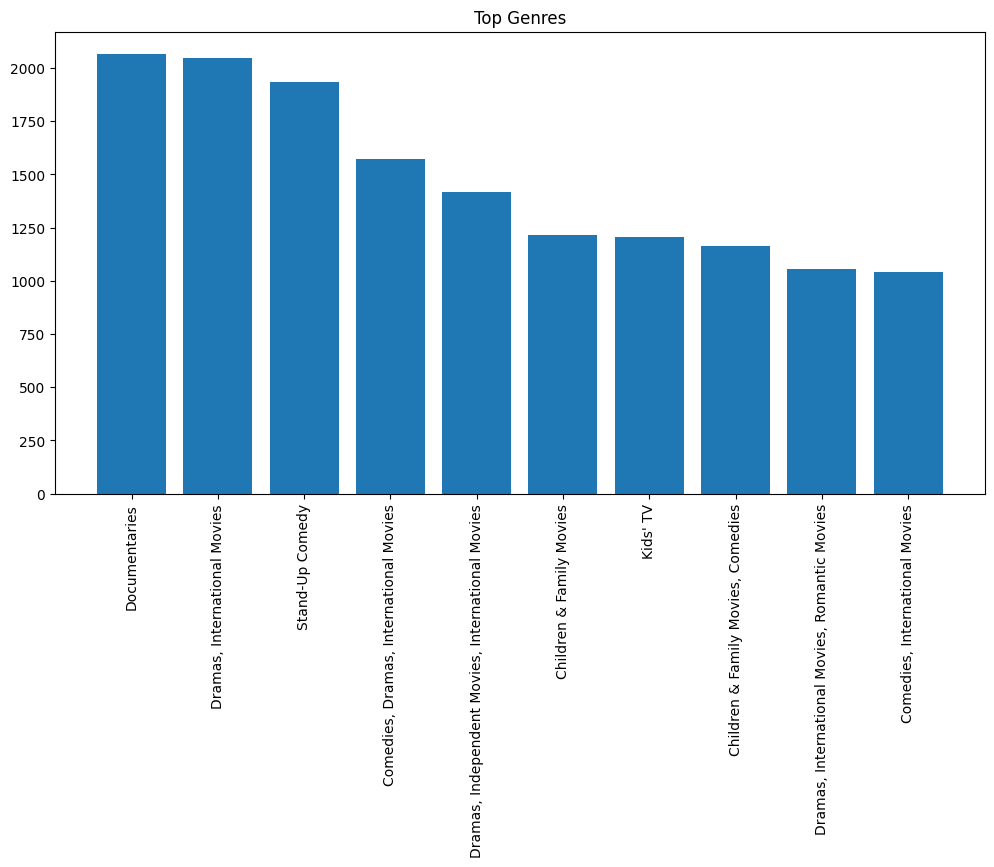

In [ ]:
import matplotlib.pyplot as plt

popular_pd = popular \
    .orderBy("views",ascending=False) \
    .limit(10) \
    .toPandas()

plt.figure(figsize=(12,6))

plt.bar(
    popular_pd["listed_in"],
    popular_pd["views"]
)

plt.xticks(rotation=90)

plt.title(
    "Top Genres"
)

plt.show()

In [ ]:
ratings = watch_df.select(
    "user_id",
    "movie_id",
    "rating"
)

train,test = ratings.randomSplit(
    [0.8,0.2],
    seed=42
)

In [ ]:
from pyspark.ml.recommendation import ALS

als = ALS(
    userCol="user_id",
    itemCol="movie_id",
    ratingCol="rating",
    coldStartStrategy="drop",
    nonnegative=True
)

model = als.fit(train)

In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator

predictions = model.transform(test)

evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)

rmse = evaluator.evaluate(predictions)

print("RMSE =", rmse)

RMSE = 1.878041325256228


In [ ]:
recommendations = model.recommendForAllUsers(5)

recommendations.show(truncate=False)

+-------+----------------------------------------------------------------------------------------------+
|user_id|recommendations                                                                               |
+-------+----------------------------------------------------------------------------------------------+
|1      |[{4011, 6.0507812}, {2443, 5.6251335}, {2395, 5.573367}, {8357, 5.533086}, {8364, 5.506979}]  |
|2      |[{8309, 5.5849934}, {4558, 5.50954}, {5833, 5.4397984}, {4965, 5.40366}, {7558, 5.286832}]    |
|3      |[{3664, 6.0798845}, {8712, 5.8364134}, {4555, 5.7733836}, {3857, 5.687824}, {7006, 5.599661}] |
|4      |[{5283, 6.0096087}, {4242, 5.8480573}, {6670, 5.731324}, {8045, 5.705099}, {3675, 5.669624}]  |
|5      |[{8687, 5.9472685}, {3776, 5.940522}, {3288, 5.8959293}, {3240, 5.7506433}, {1303, 5.6370063}]|
|6      |[{5049, 5.5671945}, {3472, 5.495766}, {4929, 5.3641305}, {1169, 5.345155}, {3947, 5.3289337}] |
|7      |[{3753, 5.730413}, {6741, 5.411678}, {4349, 5.

In [ ]:
movies_pd = netflix_df.select(
    "movie_id",
    "title"
).toPandas()

movies_dict = dict(
    zip(
        movies_pd["movie_id"],
        movies_pd["title"]
    )
)

In [ ]:
user1 = recommendations.filter(
    recommendations.user_id == 1
).collect()[0]

for rec in user1["recommendations"]:
    print(
        movies_dict.get(rec["movie_id"]),
        "- Predicted Rating:",
        round(rec["rating"],2)
    )

LeapFrog: Letter Factory - Predicted Rating: 6.05
Finally Found Someone - Predicted Rating: 5.63
Fate: The Winx Saga - The Afterparty - Predicted Rating: 5.57
Velvet Colección - Predicted Rating: 5.53
Very Big Shot - Predicted Rating: 5.51


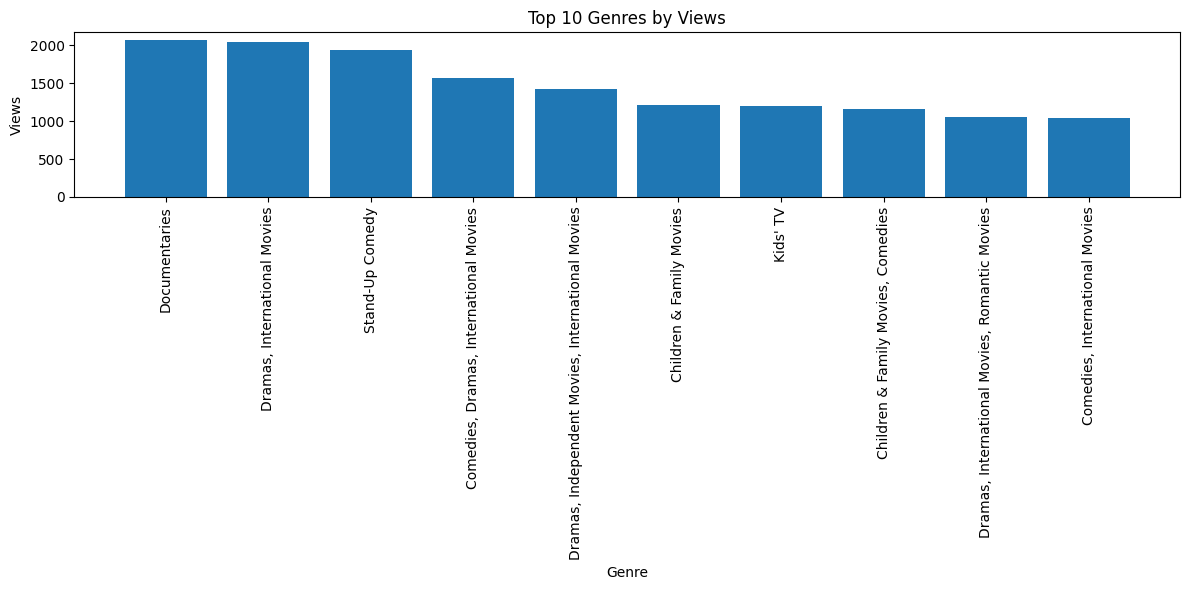

In [ ]:
from pyspark.sql.functions import count
import matplotlib.pyplot as plt

genre_views = joined.groupBy(
    "listed_in"
).agg(
    count("*").alias("views")
)

top_genres = genre_views.orderBy(
    "views",
    ascending=False
).limit(10)

genre_pd = top_genres.toPandas()

plt.figure(figsize=(12,6))

plt.bar(
    genre_pd["listed_in"],
    genre_pd["views"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Genres by Views")

plt.xlabel("Genre")

plt.ylabel("Views")

plt.tight_layout()

plt.show()

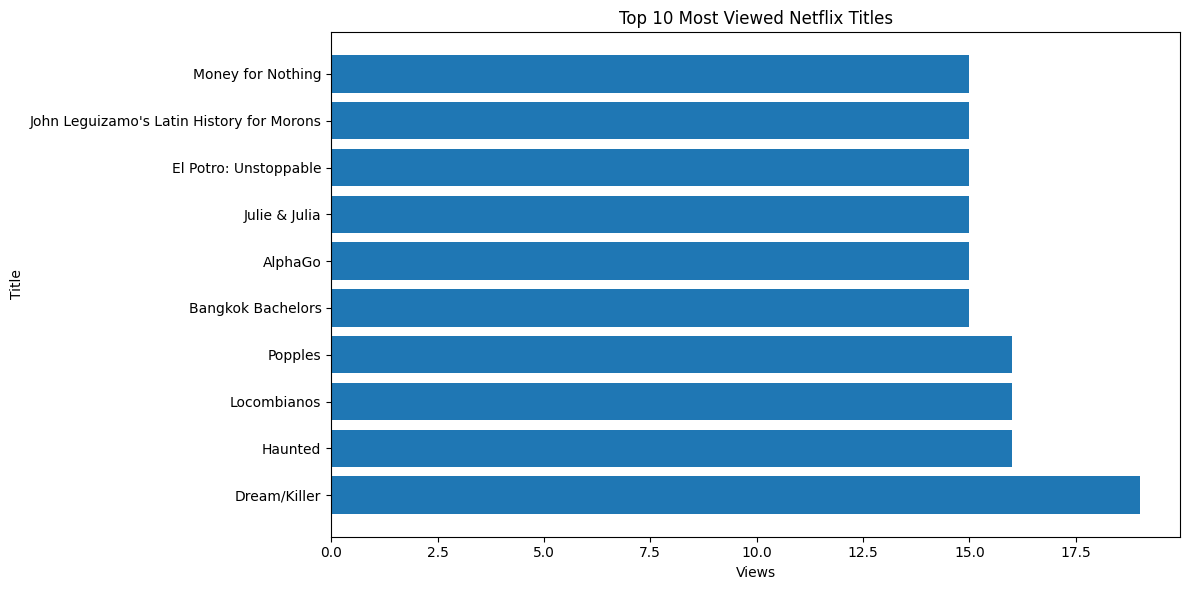

In [ ]:
from pyspark.sql.functions import count

top_movies = joined.groupBy(
    "title"
).agg(
    count("*").alias("views")
)

top_movies = top_movies.orderBy(
    "views",
    ascending=False
).limit(10)

movies_pd = top_movies.toPandas()

plt.figure(figsize=(12,6))

plt.barh(
    movies_pd["title"],
    movies_pd["views"]
)

plt.title("Top 10 Most Viewed Netflix Titles")

plt.xlabel("Views")

plt.ylabel("Title")

plt.tight_layout()

plt.show()

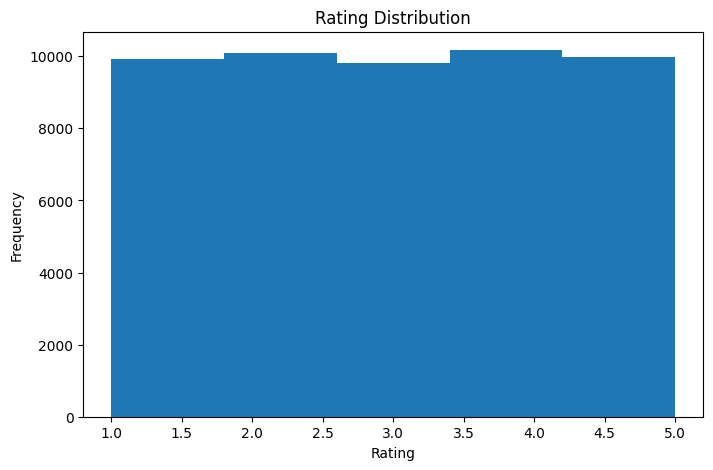

In [ ]:
ratings_pd = watch_df.toPandas()

plt.figure(figsize=(8,5))

plt.hist(
    ratings_pd["rating"],
    bins=5
)

plt.title("Rating Distribution")

plt.xlabel("Rating")

plt.ylabel("Frequency")

plt.show()

In [ ]:
movies_pd = netflix_df.select(
    "movie_id",
    "title"
).toPandas()

movies_dict = dict(
    zip(
        movies_pd["movie_id"],
        movies_pd["title"]
    )
)

user1 = recommendations.filter(
    recommendations.user_id == 1
).collect()[0]

print("Top Recommendations for User 1\n")

for rec in user1["recommendations"]:
    print(
        movies_dict.get(rec["movie_id"]),
        " | Predicted Rating:",
        round(rec["rating"],2)
    )

Top Recommendations for User 1

LeapFrog: Letter Factory  | Predicted Rating: 6.05
Finally Found Someone  | Predicted Rating: 5.63
Fate: The Winx Saga - The Afterparty  | Predicted Rating: 5.57
Velvet Colección  | Predicted Rating: 5.53
Very Big Shot  | Predicted Rating: 5.51
